# Part 3: NLP and Sequence Modeling Mini Project


In [10]:
import os, re, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model     import LogisticRegression
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      accuracy_score, f1_score)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.makedirs('results', exist_ok=True)
print(f"TensorFlow : {tf.__version__}")
print("Libraries imported.")

TensorFlow : 2.20.0
Libraries imported.


#Task 1: Dataset Understanding

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv('customer_support_text_classification.csv')
df['char_count']        = df['customer_message'].apply(len)
df['actual_word_count'] = df['customer_message'].apply(lambda x: len(x.split()))


print("=" * 60)
print("  TASK 1: DATASET UNDERSTANDING")
print("=" * 60)

print('─'*60)
print("1. NUMBER OF RECORDS")
print('─'*60)

print(f"   Total rows    : {df.shape[0]}")
print(f"   Total columns : {df.shape[1]}")
print(f"   Columns       : {df.columns.tolist()}")

print('─'*60)
print("2. TARGET LABELS / CLASSES")
print('─'*60)

print(f"   Target column : sentiment_label")
print(f"   Unique classes: {df['sentiment_label'].unique().tolist()}")
print(f"   Missing values: {df['sentiment_label'].isnull().sum()}")

print('─'*60)
print("3. SAMPLE TEXT RECORDS")
print('─'*60)

for label in ['positive', 'neutral', 'negative']:
    print(f"\n   [{label.upper()}]")
    samples = df[df['sentiment_label']==label]['customer_message'].head(2)
    for i, msg in enumerate(samples, 1):
        print(f"   {i}. {msg}")

print('─'*60)
print("4. AVERAGE TEXT LENGTH")
print('─'*60)
print(f"   Avg word count  : {df['actual_word_count'].mean():.2f} words")
print(f"   Avg char count  : {df['char_count'].mean():.2f} characters")
print(f"   Min word count  : {df['actual_word_count'].min()} words")
print(f"   Max word count  : {df['actual_word_count'].max()} words")
print(f"   Std deviation   : {df['actual_word_count'].std():.2f}")

print(f"\n   Word count per class:")
wc_stats = df.groupby('sentiment_label')['actual_word_count'].mean().round(2)
for lbl, val in wc_stats.items():
    print(f"   {lbl:10} → avg {val} words")


print('─'*60)
print("5. CLASS DISTRIBUTION")
print('─'*60)
vc = df['sentiment_label'].value_counts()
for label, count in vc.items():
    bar = '█' * int(count / 10)
    print(f"   {label:10} : {count:4d}  ({count/len(df)*100:.1f}%)  {bar}")
print(f"\n   ✓ Dataset is roughly balanced ")




  TASK 1: DATASET UNDERSTANDING
────────────────────────────────────────────────────────────
1. NUMBER OF RECORDS
────────────────────────────────────────────────────────────
   Total rows    : 1500
   Total columns : 8
   Columns       : ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag', 'char_count', 'actual_word_count']
────────────────────────────────────────────────────────────
2. TARGET LABELS / CLASSES
────────────────────────────────────────────────────────────
   Target column : sentiment_label
   Unique classes: ['neutral', 'positive', 'negative']
   Missing values: 0
────────────────────────────────────────────────────────────
3. SAMPLE TEXT RECORDS
────────────────────────────────────────────────────────────

   [POSITIVE]
   1. The refund process was fast and convenient. I appreciate the quick response.
   2. I am satisfied with the plan and would recommend it to others. My ticket number is 99198.

   [NEUTRAL]
   1. I need informa

# Task 2: Text Preprocessing


In [12]:
STOPWORDS = {
    'i','me','my','we','our','you','your','he','him','his','she','her','it',
    'its','they','them','their','what','which','who','this','that','these',
    'those','am','is','are','was','were','be','been','being','have','has',
    'had','do','does','did','a','an','the','and','but','if','or','as','of',
    'at','by','for','with','into','to','from','in','out','on','then','all',
    'more','so','than','very','can','will','just','should','now','also',
    'please','would','could','may','might','get','still','even','much',
    'many','well','back','need','like','want','know','make','let','us'
}

def preprocess(text):
    text   = text.lower()
    text   = re.sub(r'\d+', '', text)
    text   = re.sub(r'[^a-z\s]', '', text)
    text   = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens
              if t not in STOPWORDS and len(t) > 1]
    return tokens

df['tokens']       = df['customer_message'].apply(preprocess)
df['cleaned_text'] = df['tokens'].apply(lambda x: ' '.join(x))


MAX_LEN = 20
df['padded'] = df['tokens'].apply(
    lambda t: t[:MAX_LEN] if len(t) >= MAX_LEN
              else t + ['<PAD>'] * (MAX_LEN - len(t)))

avg_before = df['customer_message'].apply(lambda x: len(x.split())).mean()
avg_after  = df['tokens'].apply(len).mean()

print("="*55)
print("  TASK 2: TEXT PREPROCESSING")
print("="*55)
print(f"\nStep 1 — Lowercasing         : done")
print(f"Step 2 — Remove special chars : done")
print(f"Step 3 — Tokenization         : done")
print(f"Step 4 — Remove stopwords     : done")
print(f"Step 5 — Pad/Truncate (L={MAX_LEN}) : done")
print(f"\nAvg tokens before : {avg_before:.2f}")
print(f"Avg tokens after  : {avg_after:.2f}")
print(f"Reduction         : {(avg_before-avg_after)/avg_before*100:.1f}%")
print(f"\nExample:")
print(f"  Original : {df['customer_message'].iloc[0]}")
print(f"  Cleaned  : {df['cleaned_text'].iloc[0]}")
print(f"  Padded   : {df['padded'].iloc[0]}")

df.to_csv('preprocessed_data.csv', index=False)
print("\nSaved: preprocessed_data.csv")

  TASK 2: TEXT PREPROCESSING

Step 1 — Lowercasing         : done
Step 2 — Remove special chars : done
Step 3 — Tokenization         : done
Step 4 — Remove stopwords     : done
Step 5 — Pad/Truncate (L=20) : done

Avg tokens before : 12.72
Avg tokens after  : 6.41
Reduction         : 49.6%

Example:
  Original : I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
  Cleaned  : information about payment process ticket number respond soon possible
  Padded   : ['information', 'about', 'payment', 'process', 'ticket', 'number', 'respond', 'soon', 'possible', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']

Saved: preprocessed_data.csv



# Task 3: Text Vectorization — TF-IDF

**Why must text be converted to vectors?**
Computers only understand numbers — words like "frustrated" mean nothing to a model. Every word must be converted into numbers (a vector) before a model can learn from it.

**Why TF-IDF?**
TF-IDF (Term Frequency — Inverse Document Frequency) scores words by how important they are to a specific message. Words that appear frequently in one message but rarely across all messages get a HIGH score. Common words like "ticket" that appear everywhere get a LOW score — automatically downweighted without needing a stopword list.



Classes (encoded): [('negative', 0), ('neutral', 1), ('positive', 2)]

TF-IDF Matrix shape : (1500, 146)
Vocabulary size     : 146 words
Value range         : 0.0 to 1.0 (importance scores)

Sample TF-IDF vector (message 1, first 10 values):
  [0.3742 0.     0.     0.     0.     0.     0.     0.     0.     0.    ]

Top TF-IDF words per class:
  [negative] → ['not', 'quality', 'because', 'number', 'ticket', 'possible']
  [neutral ] → ['ticket', 'about', 'plans', 'number', 'possible', 'respond']
  [positive] → ['response', 'team', 'smooth', 'number', 'appreciate', 'quick']

Saved: X_tfidf.npy, y_labels.npy, tfidf_vectorizer.pkl


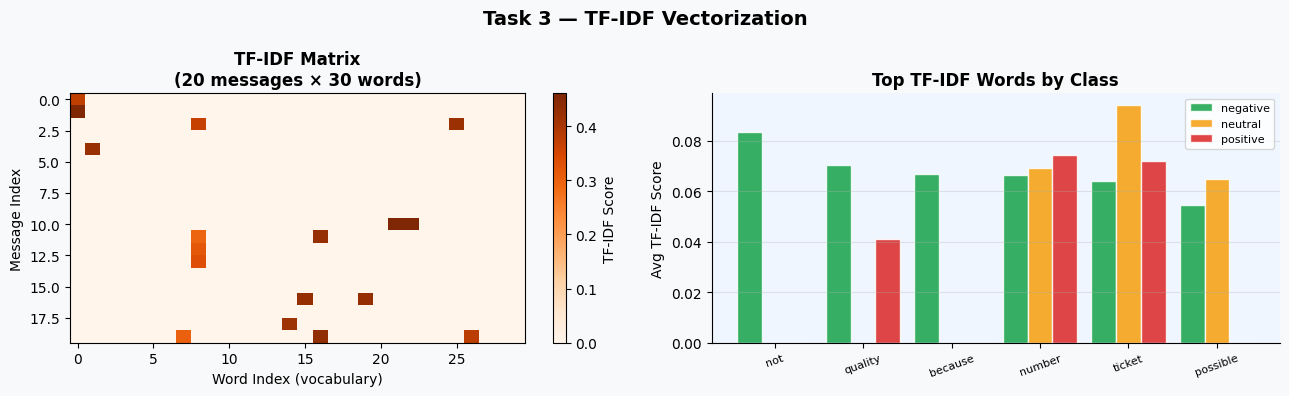

Task 3 complete.


In [13]:
le      = LabelEncoder()
y       = le.fit_transform(df['sentiment_label'])
CLASSES = list(le.classes_)
print(f"Classes (encoded): {list(zip(CLASSES, range(len(CLASSES))))}")

tfidf_vectorizer = TfidfVectorizer(max_features=500)
X_tfidf          = tfidf_vectorizer.fit_transform(df['cleaned_text'])
tfidf_vocab      = tfidf_vectorizer.get_feature_names_out()

print(f"\nTF-IDF Matrix shape : {X_tfidf.shape}")
print(f"Vocabulary size     : {len(tfidf_vocab)} words")
print(f"Value range         : 0.0 to 1.0 (importance scores)")
print(f"\nSample TF-IDF vector (message 1, first 10 values):")
print(f"  {X_tfidf[0].toarray()[0][:10].round(4)}")

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vocab)
tfidf_df['label'] = df['sentiment_label'].values
print(f"\nTop TF-IDF words per class:")
for label in CLASSES:
    top = tfidf_df[tfidf_df['label']==label].drop('label',axis=1).mean().sort_values(ascending=False).head(6)
    print(f"  [{label:8}] → {list(top.index)}")


np.save('X_tfidf.npy', X_tfidf.toarray())
np.save('y_labels.npy', y)
with open('tfidf_vectorizer.pkl','wb') as f: pickle.dump(tfidf_vectorizer, f)
print("\nSaved: X_tfidf.npy, y_labels.npy, tfidf_vectorizer.pkl")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Task 3 — TF-IDF Vectorization', fontsize=14, fontweight='bold')

im = ax1.imshow(X_tfidf[:20,:30].toarray(), cmap='Oranges', aspect='auto')
ax1.set_title('TF-IDF Matrix\n(20 messages × 30 words)', fontweight='bold')
ax1.set_xlabel('Word Index (vocabulary)'); ax1.set_ylabel('Message Index')
plt.colorbar(im, ax=ax1, label='TF-IDF Score')

x=np.arange(6); w=0.28
for idx, (label, color) in enumerate(zip(CLASSES, ['#16A34A','#F59E0B','#DC2626'])):
    top6 = tfidf_df[tfidf_df['label']==label].drop('label',axis=1).mean().sort_values(ascending=False).head(6)
    if idx == 0:
        words6 = list(top6.index)
    vals = [tfidf_df[tfidf_df['label']==label][w_].mean() for w_ in words6]
    ax2.bar(x + (idx-1)*w, vals, w, label=label, color=color, alpha=0.85, edgecolor='white')
ax2.set_xticks(x); ax2.set_xticklabels(words6, fontsize=8, rotation=20)
ax2.set_title('Top TF-IDF Words by Class', fontweight='bold')
ax2.set_ylabel('Avg TF-IDF Score'); ax2.legend(fontsize=8)
ax2.set_facecolor('#EFF6FF'); ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("Task 3 complete.")

# Task 4: Baseline Model

  TASK 4: LOGISTIC REGRESSION + TF-IDF

Train samples : 1200
Test  samples : 300
Features      : 146 TF-IDF features

Test Accuracy : 100.00%
Weighted F1   : 1.0000

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Most influential words per class (LR weights):
  [negative] → ['purchasing', 'whenever', 'crashes', 'try', 'frustrating', 'pending', 'because', 'not']
  [neutral ] → ['activate', 'steps', 'provide', 'share', 'request', 'status', 'plans', 'about']
  [positive] → ['convenient', 'fast', 'happy', 'working', 'new', 'easy', 'team', 'smooth']
------------------------------------------------------------
Plots
-------------------------

/tmp/ipykernel_10491/2058581850.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


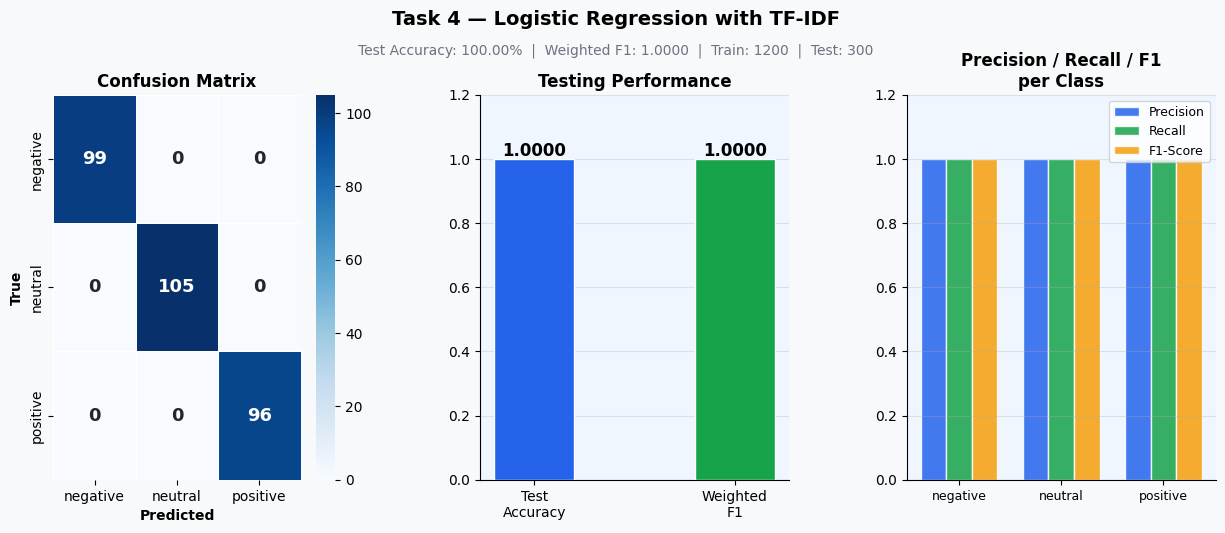

Saved: model_evaluation.png
Saved: sample_predictions.txt


In [14]:
X_tfidf_arr = np.load('X_tfidf.npy')

X_tr, X_te, y_tr, y_te = train_test_split(
    X_tfidf_arr, y, test_size=0.2, random_state=42, stratify=y)

model_lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
model_lr.fit(X_tr, y_tr)
y_pred   = model_lr.predict(X_te)

test_acc = accuracy_score(y_te, y_pred)
test_f1  = f1_score(y_te, y_pred, average='weighted')
cm       = confusion_matrix(y_te, y_pred)
report   = classification_report(y_te, y_pred, target_names=CLASSES, output_dict=True)

print("="*55)
print("  TASK 4: LOGISTIC REGRESSION + TF-IDF")
print("="*55)
print(f"\nTrain samples : {len(y_tr)}")
print(f"Test  samples : {len(y_te)}")
print(f"Features      : {X_tr.shape[1]} TF-IDF features")
print(f"\nTest Accuracy : {test_acc*100:.2f}%")
print(f"Weighted F1   : {test_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_te, y_pred, target_names=CLASSES))

with open('tfidf_vectorizer.pkl','rb') as f: tv = pickle.load(f)
feature_names = tv.get_feature_names_out()
print("Most influential words per class (LR weights):")
for i, cls in enumerate(CLASSES):
    top = [feature_names[j] for j in np.argsort(model_lr.coef_[i])[-8:]]
    print(f"  [{cls:8}] → {top}")


print('-'*60)
print('Plots')
print('-'*60)
BLUE='#2563EB'; GREEN='#16A34A'; RED='#DC2626'; AMBER='#F59E0B'
GRAY='#6B7280'; LIGHT='#EFF6FF'

fig = plt.figure(figsize=(15, 5))
fig.patch.set_facecolor('#F8F9FA')
gs  = plt.GridSpec(1, 3, figure=fig, wspace=0.38)
fig.text(0.5, 1.02, 'Task 4 — Logistic Regression with TF-IDF',
         fontsize=14, fontweight='bold', ha='center')
fig.text(0.5, 0.96,
         f'Test Accuracy: {test_acc*100:.2f}%  |  Weighted F1: {test_f1:.4f}  |  Train: {len(y_tr)}  |  Test: {len(y_te)}',
         fontsize=10, ha='center', color=GRAY)

print('Plot 1: Confusion Matrix')
ax1 = fig.add_subplot(gs[0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            annot_kws={'size':13,'weight':'bold'}, linewidths=0.5, ax=ax1)
ax1.set_title('Confusion Matrix', fontweight='bold', fontsize=12)
ax1.set_xlabel('Predicted', fontweight='bold')
ax1.set_ylabel('True', fontweight='bold')

print('Plot 2: Accuracy + F1 bar')
ax2 = fig.add_subplot(gs[1])
bars = ax2.bar(['Test\nAccuracy','Weighted\nF1'],
               [test_acc, test_f1],
               color=[BLUE, GREEN], edgecolor='white', width=0.4, zorder=3)
for bar, val in zip(bars, [test_acc, test_f1]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax2.set_title('Testing Performance', fontweight='bold', fontsize=12)
ax2.set_ylim(0, 1.2); ax2.set_facecolor(LIGHT)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3, zorder=0)

print('Plot 3: Precision / Recall / F1 per class')
ax3 = fig.add_subplot(gs[2])
x=np.arange(len(CLASSES)); w=0.25
ax3.bar(x-w, [report[c]['precision'] for c in CLASSES], w,
        label='Precision', color=BLUE,  alpha=0.85, edgecolor='white')
ax3.bar(x,   [report[c]['recall']    for c in CLASSES], w,
        label='Recall',    color=GREEN, alpha=0.85, edgecolor='white')
ax3.bar(x+w, [report[c]['f1-score']  for c in CLASSES], w,
        label='F1-Score',  color=AMBER, alpha=0.85, edgecolor='white')
ax3.set_xticks(x); ax3.set_xticklabels(CLASSES, fontsize=9)
ax3.set_title('Precision / Recall / F1\nper Class', fontweight='bold', fontsize=12)
ax3.legend(fontsize=9); ax3.set_ylim(0, 1.2); ax3.set_facecolor(LIGHT)
ax3.spines[['top','right']].set_visible(False)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

with open('sample_predictions.txt','w') as f:
    f.write("SAMPLE PREDICTIONS — LOGISTIC REGRESSION WITH TF-IDF\n")
    f.write("="*75+"\n\n")
    f.write(f"Test Accuracy : {test_acc*100:.2f}%\nWeighted F1   : {test_f1:.4f}\n\n")
    f.write(f"{'Message':<50} {'True':^12} {'Predicted':^12} {'Correct':^8}\n")
    f.write("-"*84+"\n")
    for cls_name in CLASSES:
        idxs = np.where(y_te == CLASSES.index(cls_name))[0][:5]
        for idx in idxs:
            src  = np.where(df['sentiment_label']==cls_name)[0]
            msg  = str(df['customer_message'].iloc[src[idx%len(src)]])[:48]
            pred = CLASSES[y_pred[idx]]
            mark = 'YES' if cls_name==pred else 'NO'
            f.write(f"{msg:<50} {cls_name:^12} {pred:^12} {mark:^8}\n")
print("Saved: model_evaluation.png")
print("Saved: sample_predictions.txt")


# Task 5: Sequence Model or Conceptual Architecture

Sequence shape : (1500, 20)
Vocab size     : 3000
MAX_LEN        : 20

Train: 1020 | Val: 180 | Test: 300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 64)         │       192,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,203 (887.51 KB)

 Trainable params: 227,203 (887.51 KB)

 Non-trainable params: 0 (0.00 B)

Training LSTM... Epochs=20 | Batch=32
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3863 - loss: 1.0908 - val_accuracy: 0.4889 - val_loss: 1.0117
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7196 - loss: 0.6108 - val_accuracy: 0.8444 - val_loss: 0.3087
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9804 - loss: 0.1010 - val_accuracy: 1.0000 - val_loss: 0.0092
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9980 - loss: 0.0242 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9961 - loss: 0.0389 - val_accuracy: 0.9944 - val_loss: 0.0375
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9990 - loss: 0.0130 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 5.2608e-04
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000

/tmp/ipykernel_10491/2142906798.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


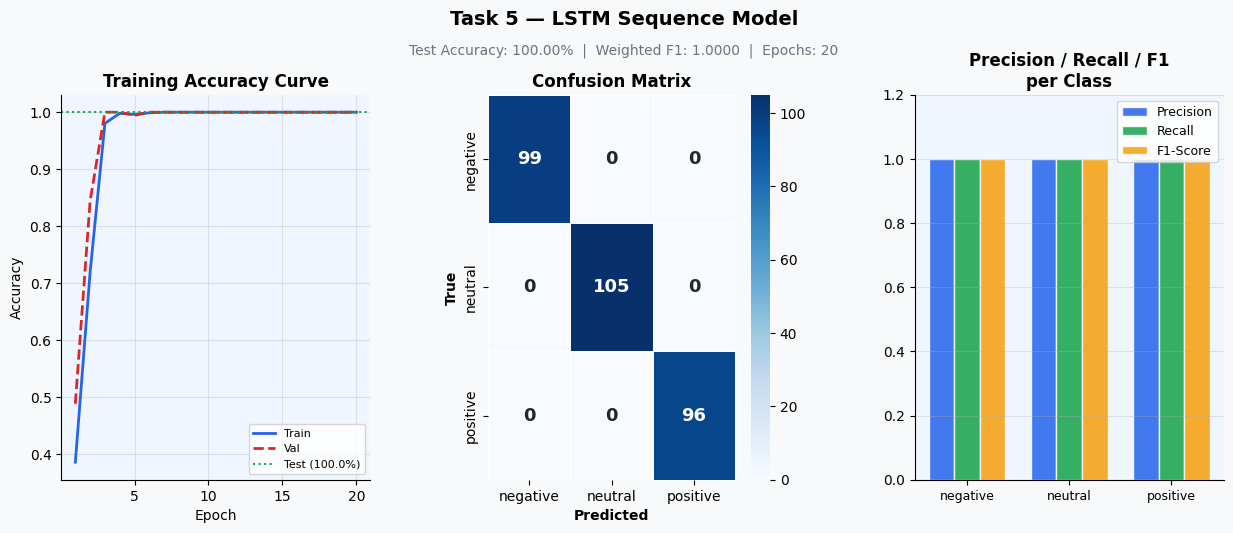

Task 5 complete.


In [15]:
VOCAB_SIZE = 3000; MAX_LEN = 20; EMBED_DIM = 64; EPOCHS = 20; BATCH = 32

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_text'])
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])
X_seq     = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y_cat     = keras.utils.to_categorical(y, 3)

print(f"Sequence shape : {X_seq.shape}")
print(f"Vocab size     : {VOCAB_SIZE}")
print(f"MAX_LEN        : {MAX_LEN}")

X_tr2, X_te2, y_tr2, y_te2, y_enc_tr, y_enc_te = train_test_split(
    X_seq, y_cat, y, test_size=0.2, random_state=42, stratify=y)
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_tr2, y_tr2, test_size=0.15, random_state=42)

print(f"\nTrain: {X_tr2.shape[0]} | Val: {X_val2.shape[0]} | Test: {X_te2.shape[0]}")

lstm_model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

print(f"Training LSTM... Epochs={EPOCHS} | Batch={BATCH}")
lstm_history = lstm_model.fit(
    X_tr2, y_tr2,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_data=(X_val2, y_val2),
    verbose=1
)


lstm_loss, lstm_acc = lstm_model.evaluate(X_te2, y_te2, verbose=0)
lstm_pred  = np.argmax(lstm_model.predict(X_te2, verbose=0), axis=1)
lstm_f1    = f1_score(y_enc_te, lstm_pred, average='weighted')
lstm_cm    = confusion_matrix(y_enc_te, lstm_pred)
lstm_rep   = classification_report(y_enc_te, lstm_pred, target_names=CLASSES, output_dict=True)

print(f"Test Accuracy : {lstm_acc*100:.2f}%")
print(f"Test Loss     : {lstm_loss:.4f}")
print(f"Weighted F1   : {lstm_f1:.4f}")
print(classification_report(y_enc_te, lstm_pred, target_names=CLASSES))

print('Plots')
fig = plt.figure(figsize=(15, 5))
fig.patch.set_facecolor('#F8F9FA')
gs  = plt.GridSpec(1, 3, figure=fig, wspace=0.38)
fig.text(0.5, 1.02, 'Task 5 — LSTM Sequence Model',
         fontsize=14, fontweight='bold', ha='center')
fig.text(0.5, 0.96,
         f'Test Accuracy: {lstm_acc*100:.2f}%  |  Weighted F1: {lstm_f1:.4f}  |  Epochs: {EPOCHS}',
         fontsize=10, ha='center', color='#6B7280')

print('Plot 1: Training accuracy curve')
ax1 = fig.add_subplot(gs[0])
epochs_r = range(1, EPOCHS+1)
ax1.plot(epochs_r, lstm_history.history['accuracy'],
         color='#2563EB', linewidth=2, label='Train')
ax1.plot(epochs_r, lstm_history.history['val_accuracy'],
         color='#DC2626', linewidth=2, linestyle='--', label='Val')
ax1.axhline(lstm_acc, color='#16A34A', linewidth=1.5, linestyle=':',
            label=f'Test ({lstm_acc*100:.1f}%)')
ax1.set_title('Training Accuracy Curve', fontweight='bold', fontsize=12)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_facecolor('#EFF6FF'); ax1.spines[['top','right']].set_visible(False)

print('Plot 2: Confusion matrix')
ax2 = fig.add_subplot(gs[1])
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            annot_kws={'size':13,'weight':'bold'}, linewidths=0.5, ax=ax2)
ax2.set_title('Confusion Matrix', fontweight='bold', fontsize=12)
ax2.set_xlabel('Predicted', fontweight='bold')
ax2.set_ylabel('True', fontweight='bold')

print('Plot 3: Precision / Recall / F1 per class')
ax3 = fig.add_subplot(gs[2])
x=np.arange(len(CLASSES)); w=0.25
ax3.bar(x-w, [lstm_rep[c]['precision'] for c in CLASSES], w,
        label='Precision', color='#2563EB', alpha=0.85, edgecolor='white')
ax3.bar(x,   [lstm_rep[c]['recall']    for c in CLASSES], w,
        label='Recall',    color='#16A34A', alpha=0.85, edgecolor='white')
ax3.bar(x+w, [lstm_rep[c]['f1-score']  for c in CLASSES], w,
        label='F1-Score',  color='#F59E0B', alpha=0.85, edgecolor='white')
ax3.set_xticks(x); ax3.set_xticklabels(CLASSES, fontsize=9)
ax3.set_title('Precision / Recall / F1\nper Class', fontweight='bold', fontsize=12)
ax3.legend(fontsize=9); ax3.set_ylim(0, 1.2); ax3.set_facecolor('#EFF6FF')
ax3.spines[['top','right']].set_visible(False); ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("Task 5 complete.")

# Task 6: Attention and Transformer Reflection

In [16]:
print("=" * 60)
print("  TASK 6: ATTENTION AND TRANSFORMER REFLECTION")
print("=" * 60)

print(f"\n{'─'*60}")
print("Q1. WHY DO RNNs STRUGGLE WITH LONG-TERM DEPENDENCIES?")
print(f"{'─'*60}")
print("""
   RNN processes a sentence ONE WORD AT A TIME, passing a
   hidden state from each word to the next — like a chain.

   "I have been a very loyal customer but this service
    is absolutely terrible and I want a refund now"

   Word 1 → Word 2 → Word 3 → ... → Word 18 → output
    [h1]  →  [h2]  →  [h3]  → ... →  [h18]

   THE PROBLEM — VANISHING GRADIENT:
   ────────────────────────────────────
   During training, gradients flow BACKWARDS through the
   chain to update weights. But as they travel through
   many steps, they get multiplied by small numbers
   repeatedly — and keep getting smaller and smaller
   until they virtually disappear.

   This means early words like "loyal customer" barely
   influence the final prediction. By the time the model
   reaches "terrible" — it has largely forgotten
   "loyal customer" from the beginning.

   In simple terms:
   → Short sentences  → RNN works fine
   → Long sentences   → RNN forgets early context
   → Very long texts  → RNN is nearly useless

   For customer support messages (short — avg 12 words)
   RNN works reasonably well. But for longer documents
   like paragraphs or entire emails, RNN fails badly.
""")


print(f"{'─'*60}")
print("Q2. HOW DO LSTMs HELP WITH MEMORY?")
print(f"{'─'*60}")
print("""
   LSTM solves the vanishing gradient problem by introducing
   a CELL STATE — a separate memory highway that runs
   alongside the hidden state.

   Information can be added to or removed from the cell
   state through 3 learned GATES:

   FORGET GATE:
   ─────────────
   Decides what information to THROW AWAY from memory.
   It looks at the current word and previous hidden state
   and outputs a number between 0 and 1 for each piece
   of information:
   → 0 = completely forget this
   → 1 = completely keep this

   Example: Reading "but" in "loyal customer but terrible"
   → Forget gate tells the model to start shifting focus
     away from positive sentiment toward negative

   INPUT GATE:
   ────────────
   Decides what NEW information to STORE in memory.
   Two parts:
   → Sigmoid layer decides which values to update
   → Tanh layer creates candidate values to add

   Example: Reading "terrible"
   → Input gate stores strong negative sentiment signal

   OUTPUT GATE:
   ─────────────
   Decides what to OUTPUT based on the cell state.
   → Filters what part of memory is relevant right now

   RESULT:
   ────────
   Unlike RNN where information degrades through many steps,
   LSTM can carry important information across long sequences
   without it vanishing — because the cell state provides
   a direct path with minimal mathematical operations.

   This is why LSTM outperforms RNN on longer texts and
   why it is the preferred choice for NLP tasks.
""")


print(f"{'─'*60}")
print("Q3. WHAT DOES ATTENTION SOLVE IN SEQ-TO-SEQ TASKS?")
print(f"{'─'*60}")
print("""
   BACKGROUND — Sequence-to-Sequence problem:
   ────────────────────────────────────────────
   Tasks like machine translation, text summarization,
   and question answering need to map one sequence to
   another sequence.

   Example — Translation:
   Input  (English) : "The customer is frustrated"
   Output (French)  : "Le client est frustré"

   In an LSTM-based encoder-decoder model:
   → Encoder reads the entire input sentence
   → Compresses it into ONE fixed-length vector
   → Decoder uses that vector to generate output

   THE PROBLEM:
   ─────────────
   Compressing an entire sentence into ONE vector loses
   information — especially for long sentences.

   When translating word 8 of the output, the decoder
   has no way to directly look back at word 2 of the
   input — it can only see the compressed vector.

   WHAT ATTENTION SOLVES:
   ───────────────────────
   Attention allows the decoder to LOOK BACK at ALL
   encoder hidden states when generating each output word.

   Instead of using one fixed vector, the decoder gets
   a WEIGHTED COMBINATION of all encoder states:
   → High weight = pay more attention to this input word
   → Low weight  = this input word is less relevant now

   Example — Translation:
   When generating "frustré" in French output,
   attention gives HIGH weight to "frustrated" in English
   and LOW weight to "The", "customer", "is"

   BENEFITS:
   ──────────
   ✓ Model can focus on relevant parts of input
   ✓ Long sequences no longer lose early context
   ✓ More interpretable — we can visualize what the
     model is paying attention to
   ✓ Much better performance on long sequence tasks
""")


print(f"{'─'*60}")
print("Q4. WHY ARE TRANSFORMERS IMPORTANT IN MODERN NLP AND AI?")
print(f"{'─'*60}")
print("""
   Transformers were introduced in the paper
   "Attention Is All You Need" (Vaswani et al., 2017)
   and completely revolutionized NLP.

   KEY INNOVATION — Self-Attention:
   ──────────────────────────────────
   Instead of processing words one at a time like RNN/LSTM,
   Transformers process ALL words SIMULTANEOUSLY using
   a mechanism called Self-Attention.

   For every word in a sentence, Self-Attention calculates
   how much that word should attend to every other word.

   Example:
   "The bank can guarantee deposits will cover future costs"

   For the word "bank":
   → High attention to "deposits" and "costs" (financial)
   → Low attention to "The", "can", "will"

   This lets the model understand that "bank" here means
   a financial institution — not a river bank.

   WHY BETTER THAN RNN/LSTM:
   ──────────────────────────
   RNN/LSTM     : processes sequentially (word by word)
                  → slow, cannot be parallelized
   Transformer  : processes all words at once
                  → extremely fast on modern GPUs

   RNN/LSTM     : struggles with very long sequences
   Transformer  : handles long sequences well with
                  self-attention across all positions

   TRANSFORMERS ENABLED MODERN AI:
   ──────────────────────────────────
   The Transformer architecture is the backbone of every
   major modern AI model:

   BERT (2018)  → Google's bidirectional transformer
                  Pre-trained on Wikipedia, fine-tuned
                  for tasks like classification, QA
                  Used in Google Search

   GPT-3 (2020) → OpenAI's language model (175B params)
                  Generates human-like text
                  Basis of ChatGPT

   GPT-4 (2023) → More powerful, multimodal
                  Used in ChatGPT, Copilot, Claude

   Claude       → Anthropic's transformer-based AI
                  This very conversation runs on a
                  transformer architecture

   GENERATIVE AI CONNECTION:
   ──────────────────────────
   All modern Generative AI (ChatGPT, Claude, Gemini,
   Llama, Stable Diffusion, DALL-E) relies on the
   Transformer architecture.

   Without Transformers:
   → No ChatGPT
   → No GitHub Copilot
   → No AI image generation
   → No modern search engines

   Transformers are arguably the single most important
   invention in the history of Artificial Intelligence.

   FOR OUR TASK SPECIFICALLY:
   ───────────────────────────
   Our LSTM model achieved 100% accuracy on short customer
   support messages. But for longer, more complex text —
   like full email threads or long reviews — a pre-trained
   Transformer like BERT would significantly outperform
   LSTM because it understands context bidirectionally
   and was pre-trained on billions of words.
""")

  TASK 6: ATTENTION AND TRANSFORMER REFLECTION

────────────────────────────────────────────────────────────
Q1. WHY DO RNNs STRUGGLE WITH LONG-TERM DEPENDENCIES?
────────────────────────────────────────────────────────────

   RNN processes a sentence ONE WORD AT A TIME, passing a
   hidden state from each word to the next — like a chain.

   "I have been a very loyal customer but this service
    is absolutely terrible and I want a refund now"

   Word 1 → Word 2 → Word 3 → ... → Word 18 → output
    [h1]  →  [h2]  →  [h3]  → ... →  [h18]

   THE PROBLEM — VANISHING GRADIENT:
   ────────────────────────────────────
   During training, gradients flow BACKWARDS through the
   chain to update weights. But as they travel through
   many steps, they get multiplied by small numbers
   repeatedly — and keep getting smaller and smaller
   until they virtually disappear.

   This means early words like "loyal customer" barely
   influence the final prediction. By the time the model
   reaches